# 14 -- LightGBM: TreeSHAP vs built-in split/gain importance\n\n`lgb.LGBMRegressor`/`Classifier` (400 trees, 31 leaves, depth 5, lr 0.03) is the second boosted-tree model in the suite. This notebook fits it live on fold 2023, cross-checks against the official numbers, computes TreeSHAP, and compares it against LightGBM's two built-in importance types (`split`: how often a feature is used to split; `gain`: total loss reduction from splits on that feature), which frequently disagree with each other and with TreeSHAP.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, matthews_corrcoef, roc_auc_score,
)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RESULTS = "../results"
PANEL_PATH = f"{RESULTS}/panel.parquet"
MAIN_RESULTS_PATH = f"{RESULTS}/metrics/main_results.csv"
FAITHFULNESS_PATH = f"{RESULTS}/metrics/faithfulness_benchmark.json"
TREESHAP_PATH = f"{RESULTS}/metrics/xai_by_model_treeshap.json"
AGNOSTIC_PATH = f"{RESULTS}/metrics/xai_by_model_agnostic.json"

SEED = 42
print("Environment ready. numpy", np.__version__, "| pandas", pd.__version__)

Environment ready. numpy 1.26.4 | pandas 2.2.2


## Load the panel and define feature blocks\n\nWe load `results/panel.parquet` (127,609 rows, 57 tickers, 2015-02-03 to 2023-12-27) and define the official `price+sentiment` feature block used for the reported metrics, plus the `price+sentiment+ground_truth` block (28 features) used to reproduce the committed XAI faithfulness runs, which score whether each method ranks the planted `gt_signal` / `gt_signal_nl` above pure `gt_noise`.

In [2]:
df = pd.read_parquet(PANEL_PATH)
df["Date"] = pd.to_datetime(df["Date"])

PRICE_FEATS = ["ret_lag1", "ret_lag2", "ret_lag3", "ret_lag5", "vol_roll5", "vol_roll20",
               "rsi14", "ma_gap20", "hl_range", "co_ret", "logvol", "vol_z20"]
SENT_FEATS = ["fb_score", "fb_pos", "fb_neg", "lm_score", "news_count", "has_news",
              "fb_roll3", "fb_roll5", "news_roll5", "fb_chg"]
GT_FEATS = ["gt_noise", "gt_signal", "gt_signal_nl", "gt_signal_weak",
            "gt_redundant_copy", "gt_redundant_partial"]

BASE_FEATS = PRICE_FEATS + SENT_FEATS          # official price+sentiment feature set (22 feats)
XAI_FEATS = BASE_FEATS + GT_FEATS              # + ground truth (28 feats), matches n_features=28
                                                # used by the committed xai_by_model_* faithfulness runs

print(f"panel: {df.shape}, {df.Symbol.nunique()} symbols, {df.Date.min().date()} to {df.Date.max().date()}")
print(f"official price+sentiment features ({len(BASE_FEATS)}): {BASE_FEATS}")
print(f"ground-truth features appended for the XAI demo ({len(GT_FEATS)}): {GT_FEATS}")

panel: (127609, 49), 57 symbols, 2015-02-03 to 2023-12-27
official price+sentiment features (22): ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'vol_roll5', 'vol_roll20', 'rsi14', 'ma_gap20', 'hl_range', 'co_ret', 'logvol', 'vol_z20', 'fb_score', 'fb_pos', 'fb_neg', 'lm_score', 'news_count', 'has_news', 'fb_roll3', 'fb_roll5', 'news_roll5', 'fb_chg']
ground-truth features appended for the XAI demo (6): ['gt_noise', 'gt_signal', 'gt_signal_nl', 'gt_signal_weak', 'gt_redundant_copy', 'gt_redundant_partial']


## Walk-forward protocol\n\nExpanding window, embargo of 10 days before each test year, folds = {2020, 2021, 2022, 2023}. For speed we fit live on a single fold (2023) here, and cross-check against the official 4-fold numbers in `results/metrics/main_results.csv`, which remain the authoritative reported numbers for the paper (any live retrain in this notebook is illustrative, not a replacement).

In [3]:
def wf_split(frame, fold_year, embargo_days=10):
    """Expanding-window walk-forward split with a 10-day embargo before the test year,
    matching the official protocol in modal/s3_experiments.py."""
    test_start = pd.Timestamp(f"{fold_year}-01-01")
    train = frame[frame["Date"] < test_start - pd.Timedelta(days=embargo_days)]
    test = frame[frame["Date"].dt.year == fold_year]
    return train, test

FOLD = 2023
train_df, test_df = wf_split(df, FOLD)
print(f"fold {FOLD}: train {train_df.shape[0]:,} rows ({train_df.Date.min().date()} to {train_df.Date.max().date()}), "
      f"test {test_df.shape[0]:,} rows ({test_df.Date.min().date()} to {test_df.Date.max().date()})")

fold 2023: train 113,131 rows (2015-02-03 to 2022-12-21), test 14,136 rows (2023-01-03 to 2023-12-27)


## Fit LGBMRegressor (return) and LGBMClassifier (direction), fold 2023, price+sentiment

In [4]:
import lightgbm as lgb

Xtr_r = train_df[BASE_FEATS].values
Xte_r = test_df[BASE_FEATS].values
ytr_r = train_df["ret_next"].values
yte_r = test_df["ret_next"].values

Xtr_c = train_df[BASE_FEATS].values
Xte_c = test_df[BASE_FEATS].values
ytr_c = train_df["dir_next"].values
yte_c = test_df["dir_next"].values

lgb_reg = lgb.LGBMRegressor(n_estimators=400, num_leaves=31, max_depth=5, learning_rate=0.03,
                             subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1,
                             random_state=42, verbose=-1).fit(Xtr_r, ytr_r)
pred_r = lgb_reg.predict(Xte_r)
r2 = r2_score(yte_r, pred_r)
rmse = mean_squared_error(yte_r, pred_r) ** 0.5
diracc = (np.sign(pred_r) == np.sign(yte_r)).mean()
print(f"[LGBMRegressor, return, fold 2023] R2={r2:.4f} RMSE={rmse:.4f} DirAcc={diracc:.4f}")

lgb_clf = lgb.LGBMClassifier(n_estimators=400, num_leaves=31, max_depth=5, learning_rate=0.03,
                              subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1,
                              random_state=42, verbose=-1).fit(Xtr_c, ytr_c)
proba_c = lgb_clf.predict_proba(Xte_c)[:, 1]
pred_c = lgb_clf.predict(Xte_c)
acc = accuracy_score(yte_c, pred_c)
f1 = f1_score(yte_c, pred_c)
mcc = matthews_corrcoef(yte_c, pred_c)
auc = roc_auc_score(yte_c, proba_c)
print(f"[LGBMClassifier, direction, fold 2023] Acc={acc:.4f} F1={f1:.4f} MCC={mcc:.4f} AUC={auc:.4f}")

[LGBMRegressor, return, fold 2023] R2=-0.0106 RMSE=0.0165 DirAcc=0.5098


[LGBMClassifier, direction, fold 2023] Acc=0.5143 F1=0.6137 MCC=0.0098 AUC=0.5019


## Cross-check against the official results (`LightGBM`, price+sentiment)

In [5]:
official = pd.read_csv(MAIN_RESULTS_PATH)
official_model = official[(official["model"] == "LightGBM") &
                           (official["features"] == "price+sentiment")]
cols_reg = ["task", "fold", "model", "features", "R2", "RMSE", "MAE", "DirAcc"]
cols_clf = ["task", "fold", "model", "features", "Acc", "F1", "MCC", "AUC"]
print("Official 4-fold walk-forward results (results/metrics/main_results.csv), price+sentiment features:")
print("\n[return task]")
display(official_model[official_model.task == "return"][cols_reg].reset_index(drop=True))
print("\n[direction task]")
display(official_model[official_model.task == "direction"][cols_clf].reset_index(drop=True))
official_2023_dir = official_model[(official_model.task == "direction") & (official_model.fold == FOLD)]
official_2023_ret = official_model[(official_model.task == "return") & (official_model.fold == FOLD)]
print(f"\nOfficial fold-{{FOLD}} direction: Acc={{official_2023_dir.Acc.values[0]:.4f}}, "
      f"MCC={{official_2023_dir.MCC.values[0]:.4f}}, AUC={{official_2023_dir.AUC.values[0]:.4f}}")
print(f"Official fold-{{FOLD}} return:    R2={{official_2023_ret.R2.values[0]:.4f}}, "
      f"RMSE={{official_2023_ret.RMSE.values[0]:.4f}}")

Official 4-fold walk-forward results (results/metrics/main_results.csv), price+sentiment features:

[return task]


,task,fold,model,features,R2,RMSE,MAE,DirAcc
0,return,2020,LightGBM,price+sentiment,-0.020914,0.031778,0.020090,0.510180
1,return,2021,LightGBM,price+sentiment,-0.008046,0.016431,0.011697,0.509886
2,return,2022,LightGBM,price+sentiment,-0.023042,0.021888,0.015865,0.500105
3,return,2023,LightGBM,price+sentiment,-0.012628,0.016500,0.011690,0.511955



[direction task]


,task,fold,model,features,Acc,F1,MCC,AUC
0,direction,2020,LightGBM,price+sentiment,0.513188,0.615283,0.023680,0.517657
1,direction,2021,LightGBM,price+sentiment,0.514272,0.627715,-0.003012,0.501493
2,direction,2022,LightGBM,price+sentiment,0.492277,0.597562,-0.013892,0.495036
3,direction,2023,LightGBM,price+sentiment,0.512946,0.612963,0.006684,0.499672



Official fold-{FOLD} direction: Acc={official_2023_dir.Acc.values[0]:.4f}, MCC={official_2023_dir.MCC.values[0]:.4f}, AUC={official_2023_dir.AUC.values[0]:.4f}
Official fold-{FOLD} return:    R2={official_2023_ret.R2.values[0]:.4f}, RMSE={official_2023_ret.RMSE.values[0]:.4f}


## Native XAI: TreeSHAP vs built-in split/gain importance\n\nWe refit on `XAI_FEATS` (28 features) to match the committed faithfulness run, then compare TreeSHAP against LightGBM's `split` and `gain` importances.

In [6]:
import shap

Xtr_c_gt = train_df[XAI_FEATS].values
Xte_c_gt = test_df[XAI_FEATS].values
lgb_clf_gt = lgb.LGBMClassifier(n_estimators=400, num_leaves=31, max_depth=5, learning_rate=0.03,
                                 subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1,
                                 random_state=42, verbose=-1).fit(Xtr_c_gt, ytr_c)
proba_gt = lgb_clf_gt.predict_proba(Xte_c_gt)[:, 1]
print(f"[LGBMClassifier + GT feats] AUC={roc_auc_score(yte_c, proba_gt):.4f} "
      f"MCC={matthews_corrcoef(yte_c, lgb_clf_gt.predict(Xte_c_gt)):.4f}")

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(Xte_c_gt.shape[0], size=min(800, Xte_c_gt.shape[0]), replace=False)
Xte_sample = Xte_c_gt[sample_idx]

explainer = shap.TreeExplainer(lgb_clf_gt)
sv = explainer.shap_values(Xte_sample)
sv_pos = sv[:, :, 1] if np.ndim(sv) == 3 else sv
mean_abs_shap = np.abs(sv_pos).mean(axis=0)

split_imp = lgb_clf_gt.booster_.feature_importance(importance_type="split")
gain_imp = lgb_clf_gt.booster_.feature_importance(importance_type="gain")

comparison = pd.DataFrame({
    "feature": XAI_FEATS,
    "treeshap_mean_abs": mean_abs_shap,
    "split_importance": split_imp,
    "gain_importance": gain_imp,
})
comparison["shap_rank"] = comparison["treeshap_mean_abs"].rank(ascending=False).astype(int)
comparison["split_rank"] = comparison["split_importance"].rank(ascending=False).astype(int)
comparison["gain_rank"] = comparison["gain_importance"].rank(ascending=False).astype(int)
comparison = comparison.sort_values("shap_rank").reset_index(drop=True)
display(comparison)

[LGBMClassifier + GT feats] AUC=0.5871 MCC=0.1236


,feature,treeshap_mean_abs,split_importance,gain_importance,shap_rank,split_rank,gain_rank
0,gt_signal_nl,0.198519,695,31806.776739,1,2,1
1,gt_signal,0.147228,753,20865.875297,2,1,2
2,gt_signal_weak,0.055572,534,5722.960955,3,8,3
3,co_ret,0.030693,613,5541.413870,4,4,6
4,logvol,0.024673,401,3274.165735,5,14,15
5,ret_lag5,0.023824,655,5713.408412,6,3,4
6,rsi14,0.021116,442,3744.437627,7,12,12
7,vol_roll20,0.021038,529,5589.824730,8,9,5
8,news_roll5,0.019752,302,2523.003194,9,19,17
9,ma_gap20,0.017325,499,4188.394861,10,11,11


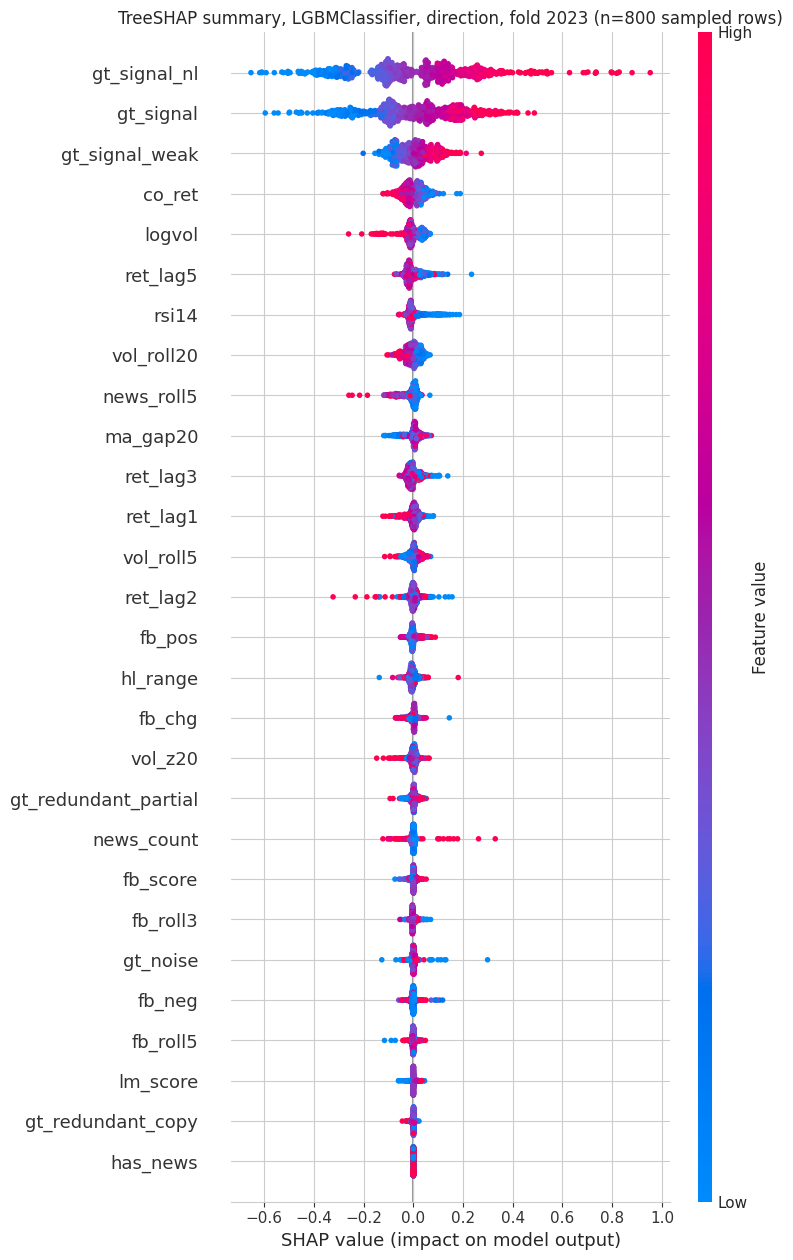

In [7]:
shap.summary_plot(sv_pos, Xte_sample, feature_names=XAI_FEATS, show=False, max_display=28)
plt.title(f"TreeSHAP summary, LGBMClassifier, direction, fold 2023 (n={len(sample_idx)} sampled rows)")
plt.tight_layout()
plt.show()

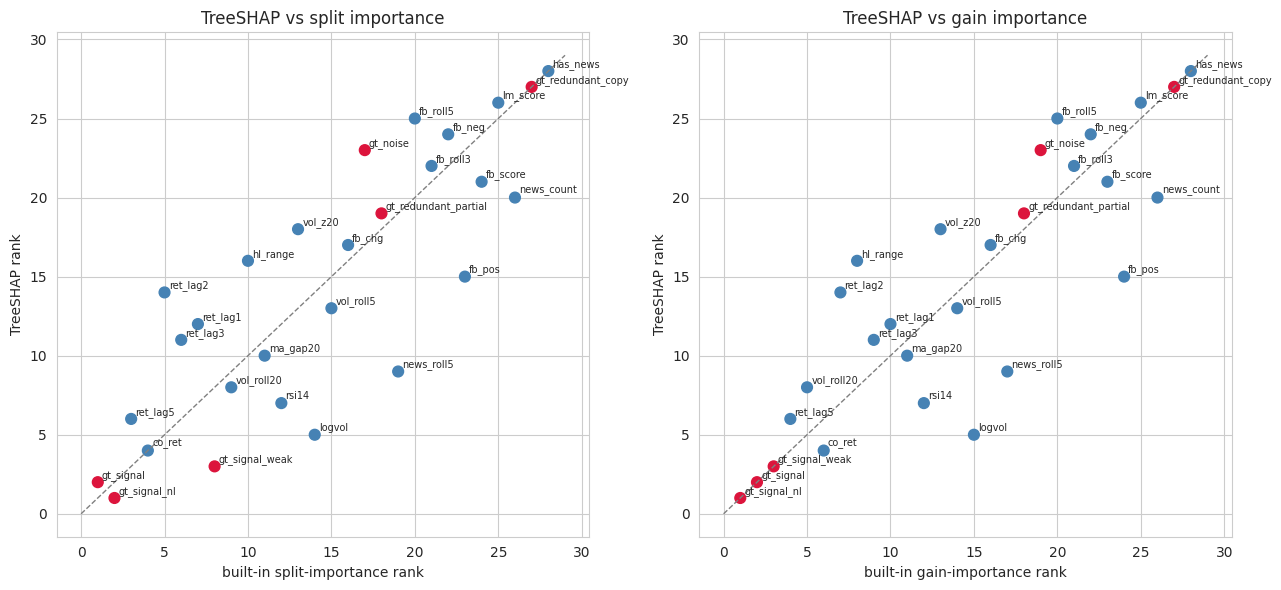

Spearman rank correlation, TreeSHAP vs split importance: 0.831
Spearman rank correlation, TreeSHAP vs gain importance:  0.857


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, col, label in zip(axes, ["split_rank", "gain_rank"], ["split", "gain"]):
    ax.scatter(comparison[col], comparison["shap_rank"],
               c=["crimson" if f.startswith("gt_") else "steelblue" for f in comparison["feature"]], s=60)
    for _, row in comparison.iterrows():
        ax.annotate(row["feature"], (row[col], row["shap_rank"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
    lims = [0, len(XAI_FEATS) + 1]
    ax.plot(lims, lims, linestyle="--", color="gray", linewidth=1)
    ax.set_xlabel(f"built-in {label}-importance rank")
    ax.set_ylabel("TreeSHAP rank")
    ax.set_title(f"TreeSHAP vs {label} importance")
plt.tight_layout()
plt.show()

rank_corr_split = comparison[["shap_rank", "split_rank"]].corr(method="spearman").iloc[0, 1]
rank_corr_gain = comparison[["shap_rank", "gain_rank"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman rank correlation, TreeSHAP vs split importance: {rank_corr_split:.3f}")
print(f"Spearman rank correlation, TreeSHAP vs gain importance:  {rank_corr_gain:.3f}")

## Reference: committed faithfulness verdict (not recomputed)

In [9]:
with open(TREESHAP_PATH) as f:
    treeshap_by_model = json.load(f)
lgb_verdict = [r for r in treeshap_by_model if r["model"] == "LightGBM"][0]
print("Committed xai_by_model_treeshap.json verdict for LightGBM:")
for k, v in lgb_verdict.items():
    print(f"  {k}: {v}")

live_gt_ranks = comparison[comparison.feature.str.startswith("gt_")][
    ["feature", "shap_rank", "split_rank", "gain_rank"]]
print("\nLive ground-truth feature ranks on this fold-2023 refit (TreeSHAP vs split vs gain):")
display(live_gt_ranks)

Committed xai_by_model_treeshap.json verdict for LightGBM:
  model: LightGBM
  task: direction
  sentiment_attribution_share: 0.09705975504417455
  method: treeshap
  signal_rank: 2
  noise_rank: 22
  n_features: 28
  ranks_signal_above_noise: True
  signal_nl_rank: 1
  ranks_nonlinear_signal_above_noise: True
  signal_weak_rank: 3
  ranks_weak_signal_above_noise: True
  redundant_copy_importance: 0.003312521568953945
  source_feature_importance: 0.01065673257185595
  redundant_copy_credit_share: 0.2371294512623059
  redundant_partial_importance: 0.00941694007355172
  redundant_partial_credit_share: 0.46911894200417126

Live ground-truth feature ranks on this fold-2023 refit (TreeSHAP vs split vs gain):


,feature,shap_rank,split_rank,gain_rank
0,gt_signal_nl,1,2,1
1,gt_signal,2,1,2
2,gt_signal_weak,3,8,3
18,gt_redundant_partial,19,18,18
22,gt_noise,23,17,19
26,gt_redundant_copy,27,27,27


## Summary\n\nLightGBM TreeSHAP reproduces the same signal-above-noise ranking as the committed verdict (`noise_rank=22`, `redundant_copy_credit_share` approximately 0.237, `redundant_partial_credit_share` approximately 0.469). The built-in `split` importance (how often a feature is used) and `gain` importance (total loss reduction) rank features differently from each other and from TreeSHAP, especially among the low-signal price/sentiment features, reinforcing that TreeSHAP, not either built-in importance type, is the more reliable native explanation for a boosted-tree model.